In [1]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import scipy.stats
import xarray as xr

from mcs_prime import mcs_prime_config_util as cu

In [2]:
ds = xr.open_dataset('/gws/nopw/j04/mcs_prime/mmuetz/data/UM_sims/u-dg135/share/cycle/20200701T0000Z/engl/um/englaa_pa.merged.20200701T0000Z.u-dg135.m01s30i461.1h-mean.nc')

In [3]:
tcwv = ds.m01s30i461.rename('tcwv')
tcwv

<xarray.DataArray 'tcwv' (realization: 10, time: 240, latitude: 324,
                          longitude: 432)>
[335923200 values with dtype=float32]
Coordinates:
  * realization              (realization) int32 0 1 2 3 4 5 6 7 8 9
  * time                     (time) datetime64[ns] 2020-07-01T03:30:00 ... 20...
  * latitude                 (latitude) float32 -89.72 -89.17 ... 89.17 89.72
  * longitude                (longitude) float32 0.4167 1.25 ... 358.7 359.6
    forecast_period          (time) timedelta64[ns] ...
    forecast_reference_time  (time) datetime64[ns] ...
Attributes:
    um_stash_source:  m01s30i461
    cell_methods:     time: mean (interval: 1 hour)
    grid_mapping:     latitude_longitude

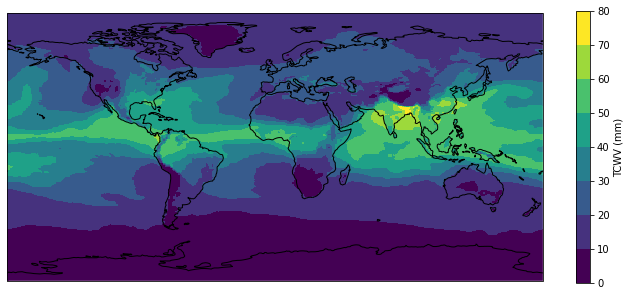

In [4]:
fig, ax = plt.subplots(figsize=(12, 5), subplot_kw={'projection': ccrs.PlateCarree()})
norm = mpl.colors.BoundaryNorm(np.arange(0, 90, 10), ncolors=256)
im = ax.pcolormesh(tcwv.longitude, tcwv.latitude, tcwv.mean(dim=['realization', 'time']), norm=norm)
plt.colorbar(im, ax=ax, label='TCWV (mm)')
ax.coastlines()

In [5]:
e5ds = xr.open_dataset('/gws/nopw/j04/mcs_prime/mmuetz/data/mcs_prime_output/era5_processed/N216grid/2020-07-01_04:00:00-2020-07-11_03:00:00/ecmwf-era5_oper_an_sfc_2020-07-01_04:00:00-2020-07-11_03:00:00.tcwv.nc')

In [8]:
e5ds.__xarray_dataarray_variable__

<xarray.DataArray '__xarray_dataarray_variable__' (time: 240, latitude: 324,
                                                   longitude: 432)>
[33592320 values with dtype=float32]
Coordinates:
  * time       (time) datetime64[ns] 2020-07-01T04:00:00 ... 2020-07-11T03:00:00
  * longitude  (longitude) float32 0.4167 1.25 2.083 2.917 ... 357.9 358.7 359.6
  * latitude   (latitude) float32 -89.72 -89.17 -88.61 ... 88.61 89.17 89.72
Attributes:
    regrid_method:        conservative
    created by:           /home/users/mmuetz/projects/mcs_prime_stoch_trigger...
    calling file source:  import pandas as pd\nfrom itertools import product\...
    project repository:   https://github.com/markmuetz/MCS_PRIME
    remake version:       ['0', '7', '0', '0', 'beta']
    remake repository:    https://github.com/markmuetz/remake
    task:                 <N216_ens_analysis.RegridERA5ToN216 object at 0x7fa...
    task doc:             Regrid ERA5 to the same grid as N216 simulations.\n...
    created on:           2024-09-20 12:23:13.262932
    nodename:             host646.jc.rl.ac.uk
    hostname:             jasmin
    output path:          /gws/nopw/j04/mcs_prime/mmuetz/data/mcs_prime_outpu...
    contact:              mark.muetzelfeldt@reading.ac.uk

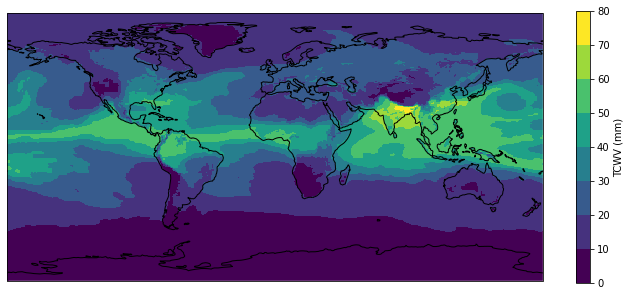

In [10]:
fig, ax = plt.subplots(figsize=(12, 5), subplot_kw={'projection': ccrs.PlateCarree()})
norm = mpl.colors.BoundaryNorm(np.arange(0, 90, 10), ncolors=256)
im = ax.pcolormesh(e5ds.longitude, e5ds.latitude, e5ds.__xarray_dataarray_variable__.mean(dim=['time']), norm=norm)
plt.colorbar(im, ax=ax, label='TCWV (mm)')
ax.coastlines()

In [13]:
SUITES = {
    'u-di727': 'ctrl',
    'u-di728': 'vanillaMCSP',
    'u-dg135': 'stochMCSP',
}
DATADIR = cu.PATHS['datadir']
SIMDIR = DATADIR / 'UM_sims'

In [18]:
tcwv_mean = {
    'ERA5': e5ds.__xarray_dataarray_variable__.mean(dim=['time']),
}
for suite in SUITES:
    print(suite)
    tcwv_path = SIMDIR / f'{suite}/share/cycle/20200701T0000Z/engl/um/englaa_pa.merged.20200701T0000Z.{suite}.m01s30i461.1h-mean.nc'
    ds = xr.open_dataset(tcwv_path)
    tcwv = ds.m01s30i461.rename('tcwv')
    tcwv_mean[SUITES[suite]] = tcwv.mean(dim=['realization', 'time'])
    

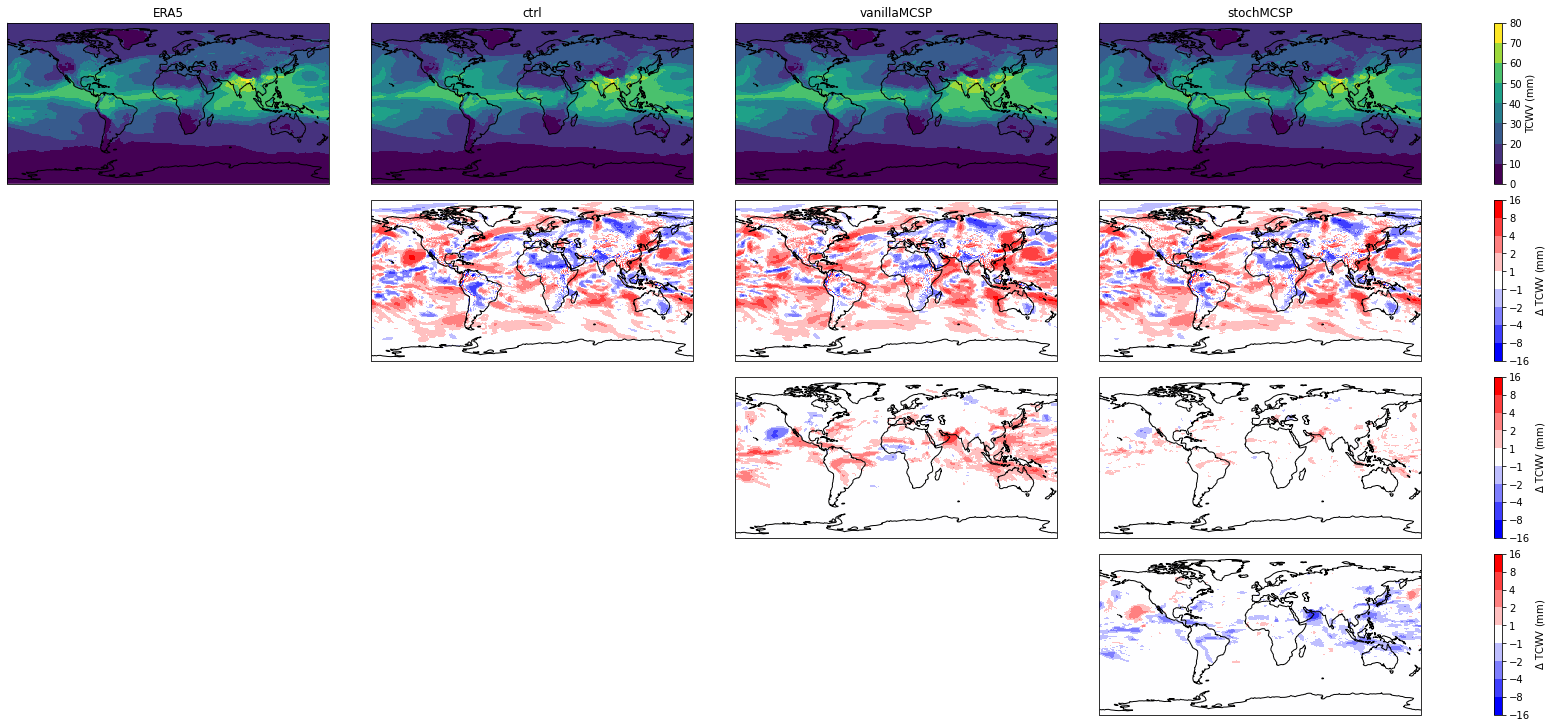

In [26]:
fig, axes = plt.subplots(4, 4, figsize=(22, 10), subplot_kw={'projection': ccrs.PlateCarree()}, layout='constrained')

norm = mpl.colors.BoundaryNorm(np.arange(0, 90, 10), ncolors=256)
for ax, (expt, tcwv) in zip(axes[0, :], tcwv_mean.items()):
    im = ax.pcolormesh(tcwv.longitude, tcwv.latitude, tcwv, norm=norm)
    ax.coastlines()
    ax.set_title(expt)
plt.colorbar(im, ax=axes[0], label='TCWV (mm)')

norm2 = mpl.colors.BoundaryNorm([-16, -8, -4, -2, -1, 1, 2, 4, 8, 16], ncolors=256)
for ax, (expt, tcwv) in zip(axes[1, 1:], list(tcwv_mean.items())[1:]):
    im = ax.pcolormesh(tcwv.longitude, tcwv.latitude, tcwv - tcwv_mean['ERA5'], norm=norm2, cmap='bwr')
    ax.coastlines()
plt.colorbar(im, ax=axes[1], label='$\Delta$ TCWV (mm)')

for ax, (expt, tcwv) in zip(axes[2, 2:], list(tcwv_mean.items())[2:]):
    im = ax.pcolormesh(tcwv.longitude, tcwv.latitude, tcwv - tcwv_mean['ctrl'], norm=norm2, cmap='bwr')
    ax.coastlines()
plt.colorbar(im, ax=axes[2], label='$\Delta$ TCWV (mm)')

for ax, (expt, tcwv) in zip(axes[3, 3:], list(tcwv_mean.items())[3:]):
    im = ax.pcolormesh(tcwv.longitude, tcwv.latitude, tcwv - tcwv_mean['vanillaMCSP'], norm=norm2, cmap='bwr')
    ax.coastlines()
plt.colorbar(im, ax=axes[3], label='$\Delta$ TCWV (mm)')

for ax in axes[np.tril_indices(4, -1)].flatten():
    ax.axis('off')
